In [ ]:
import DataHolder

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np

import cartopy.crs as ccrs

import xarray as xr
import glob

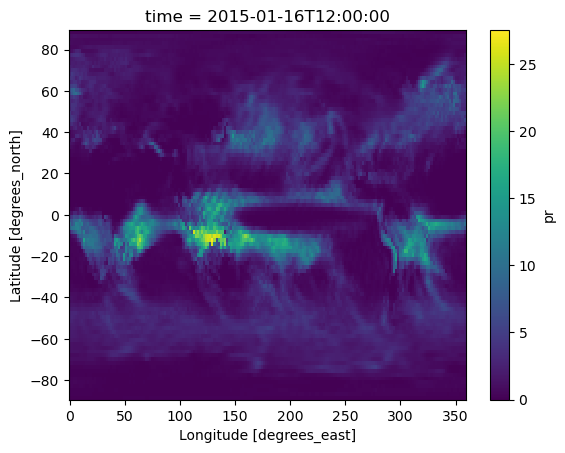

In [9]:


datafile = glob.glob('../pr_*')[0]

rawds = xr.open_dataset(datafile)

pr = 86400*rawds.pr

pr.isel(time=0).plot()

### Calculate time of emergence of summertime temperature extreme in large ensemble data

In [166]:
outputavgtime = 3
outres = 10
timerange = [1950,2080]
filefront = "MPI_"
outputvar = 'tas'
ssp = '245'

histrange = [1960,2000]

params = {
    "outres": outres,
    "ssp": ssp,
    "timerange": timerange,
    "filefront": filefront,
    "outputvar":outputvar,
}

In [167]:
imp.reload(DataHolder)
AllData = DataHolder.MPIOutputOnly(params)

summermean = AllData.summermean
lat = AllData.lat
lon = AllData.lon

In [168]:
def ensrunmean(mat,avgtime):

    shape = mat.shape
    shapeout = (shape[0],shape[1]-avgtime,shape[2],shape[3])

    matout = np.empty(shapeout)

    for ii in range(shape[1]-avgtime):
        matout[:,ii,] = np.mean(mat[:,ii:ii+avgtime],axis=1)

    return matout

In [169]:
avgtime = 3
eventthres = 90
summermeanavg = ensrunmean(summermean,avgtime)

timevec = np.arange(timerange[0],timerange[1]+1)
timecut = np.arange(timerange[0]+avgtime,timerange[1]+1)

histerainds = [histrange[0]-timecut[0],histrange[1]-timecut[0]]

histextremes = np.percentile(summermeanavg[:,histerainds[0]:histerainds[1],], q=eventthres, axis=(0,1))

#### TOE calculation

Set the time of emergence as the time when summer temperatures never again go below historical threshold

In [170]:
def toe(mat,times,extremes):

    matshape = mat.shape
    timesout = np.empty((matshape[0],matshape[2],matshape[3]))+np.nan

    for iens in range(matshape[0]):

        for ilat in range(matshape[2]):
            for ilon in range(matshape[3]):

                vecgrab = mat[iens,:,ilat,ilon]
                
                if ~np.isnan(vecgrab[0]):

                    extremegrab = extremes[ilat,ilon]
                    indgrab = max(loc for loc, val in enumerate(vecgrab) if val < extremegrab)

                    timesout[iens,ilat,ilon] = times[indgrab]

    return timesout


toes = toe(summermeanavg,timecut,histextremes)

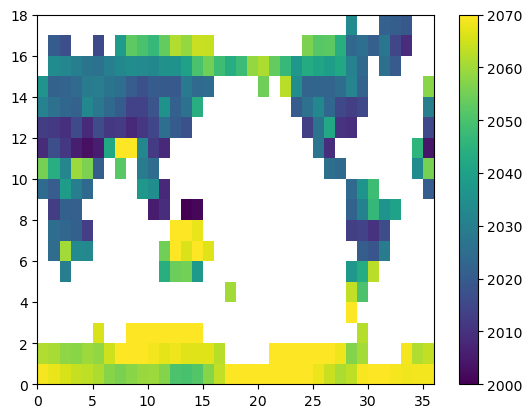

In [171]:
plt.pcolormesh(np.mean(toes,axis=0),vmin=2000,vmax=2070)
plt.colorbar()

Is the TOE calculated in each individual member the same as that calculated from the ensemble mean?

In [172]:
histextremes_mean = np.percentile(summermeanavg[:,histerainds[0]:histerainds[1],], q=eventthres, axis=(0,1))

def toe_ensmean(mat,times,extremes):

    matshape = mat.shape
    timesout = np.empty((matshape[1],matshape[2]))+np.nan

    for ilat in range(matshape[1]):
        for ilon in range(matshape[2]):

            vecgrab = mat[:,ilat,ilon]
            
            if ~np.isnan(vecgrab[0]):

                extremegrab = extremes[ilat,ilon]
                indgrab = max(loc for loc, val in enumerate(vecgrab) if val < extremegrab)

                timesout[ilat,ilon] = times[indgrab]

    return timesout

summertemp_ensmean = np.mean(summermeanavg,axis=0)

toes_ensmean = toe_ensmean(summertemp_ensmean,timecut,histextremes_mean)

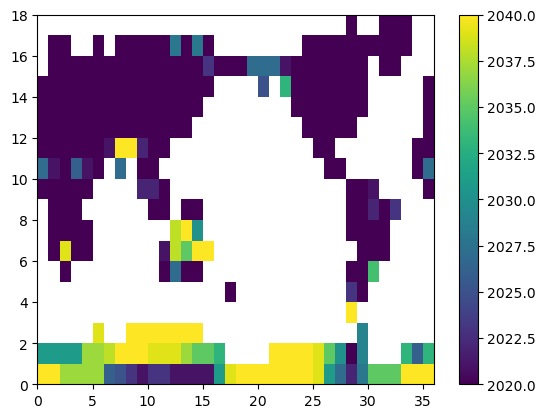

In [173]:
plt.pcolormesh(toes_ensmean,vmin=2020,vmax=2040)
plt.colorbar()

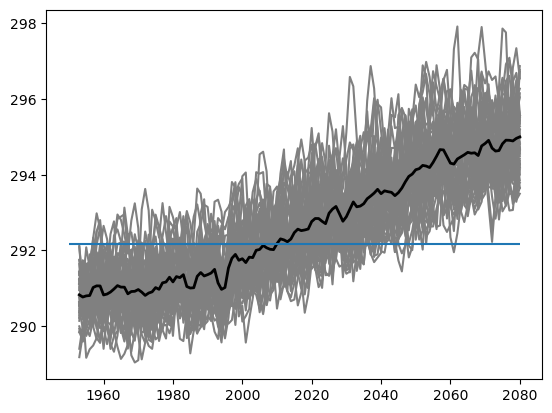

In [174]:
plt.plot(timecut,np.transpose(summermeanavg[:,:,13,25]),color='grey')
plt.plot(timecut,np.mean(summermeanavg[:,:,13,25],axis=0),color='black',linewidth=2)
plt.hlines(histextremes_mean[13,25],1950,2080)

Here calculate if finding the time series of yes/no above extreme and taking ensemble mean is the same as calculating the ensemble mean and the calculating yes/no above extreme. 

In [175]:
# yesextreme = np.copy(summermeanavg)
yesextreme = 1*(summermeanavg>histextremes[np.newaxis])

ensmeantemp = np.mean(summermeanavg,axis=0)

yesextreme_ensmean = 1*(ensmeantemp>histextremes)

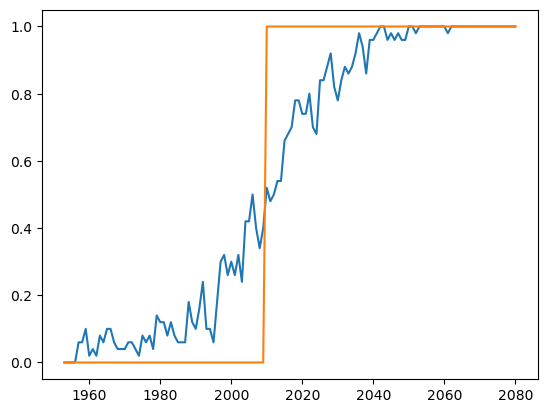

In [176]:
plt.plot(timecut,np.mean(yesextreme[:,:,13,25],axis=0))
plt.plot(timecut,yesextreme_ensmean[:,13,25])